<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Coldspell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee

In [2]:
import xarray as xr

In [ ]:
!pip install xee

In [4]:
import xee

In [5]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [6]:
# Load FAO GAUL administrative boundaries for level 1 (division level)
divisions = ee.FeatureCollection("FAO/GAUL/2015/level1")

# Filter for Bangladesh
bangladesh_divisions = divisions.filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))

# Get Barishal Division
barishal_division = bangladesh_divisions.filter(ee.Filter.eq('ADM1_NAME', 'Barisal'))

# Get Rangpur Division
rangpur_division = bangladesh_divisions.filter(ee.Filter.eq('ADM1_NAME', 'Rangpur'))


In [8]:
barishal_division

In [7]:
rangpur_division

In [10]:
# Get the geometry objects
barishal_geometry = barishal_division.geometry()
rangpur_geometry = rangpur_division.geometry()

In [12]:
print("Barishal geometry area (sq km):", barishal_geometry.area().divide(1000000).getInfo())
print("Rangpur geometry area (sq km):", rangpur_geometry.area().divide(1000000).getInfo())

Barishal geometry area (sq km): 10779.427926182012
Rangpur geometry area (sq km): 16235.46793380382


In [13]:
import folium

In [15]:
centroid = rangpur_geometry.centroid().getInfo()['coordinates']

In [16]:
lat, lon = centroid[1], centroid[0]

In [24]:
m = folium.Map(location=[lat, lon], zoom_start=8)

In [31]:
# Convert EE geometry to GeoJSON and add to map
geojson = ee.FeatureCollection([ee.Feature(rangpur_geometry)]).getInfo()
folium.GeoJson(
    geojson,
    style_function=lambda x: {
        'fillColor': 'blue',
        'color': 'red',
        'weight': 2,
        'fillOpacity': 0.2
    },
    name='Rangpur Division'
).add_to(m)

In [19]:
# Add layer control
folium.LayerControl().add_to(m)

In [21]:
# Display the map
m.save('rangpur_map.html')
print("Map saved as 'rangpur_map.html'. Open this file in your browser.")

Map saved as 'rangpur_map.html'. Open this file in your browser.


In [26]:
# Add layer control
folium.LayerControl().add_to(m)

In [30]:
display(m)

In [28]:
temp = (
    ee.ImageCollection("ECMWF/ERA5/DAILY")
    .filterDate('2010','2025')
    .select(['mean_2m_air_temperature'],['temp_air'])

)

In [29]:
temp

In [32]:
ds1 = xr.open_dataset(
    temp,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 0.11,
    geometry = rangpur_geometry
)

In [35]:
ds2 = xr.open_dataset(
    temp,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 0.11,
    geometry = barishal_geometry
)

In [36]:
ds = ds2 - 273.15

In [37]:
annual = ds.resample(time = 'YE').mean('time')

annual


<xarray.Dataset> Size: 6kB
Dimensions:   (time: 11, lon: 10, lat: 12)
Coordinates:
  * lon       (lon) float64 80B 89.91 90.02 90.13 90.24 ... 90.68 90.79 90.9
  * lat       (lat) float64 96B 21.82 21.93 22.04 22.15 ... 22.81 22.92 23.03
  * time      (time) datetime64[ns] 88B 2010-12-31 2011-12-31 ... 2020-12-31
Data variables:
    temp_air  (time, lon, lat) float32 5kB 26.76 26.76 26.62 ... 25.37 25.28
Attributes: (12/36)
    date_range:               [284083200000, 1594252800000]
    description:              <p>ERA5 is the fifth generation ECMWF atmospher...
    keywords:                 ['climate', 'copernicus', 'dewpoint', 'ecmwf', ...
    max_mirrored_version:     1594797432309553
    period:                   1
    period_mapping:           [284083200000, 1594252800000]
    ...                       ...
    visualization_3_bands:    u_component_of_wind_10m
    visualization_3_max:      30.0
    visualization_3_min:      0.0
    visualization_3_name:     Daily mean u-component of wind at 10m
    visualization_3_palette:  #FFFFFF,#FFFF71,#DEFF00,#9EFF00,#77B038,#007E55...
    crs:                      EPSG:4326

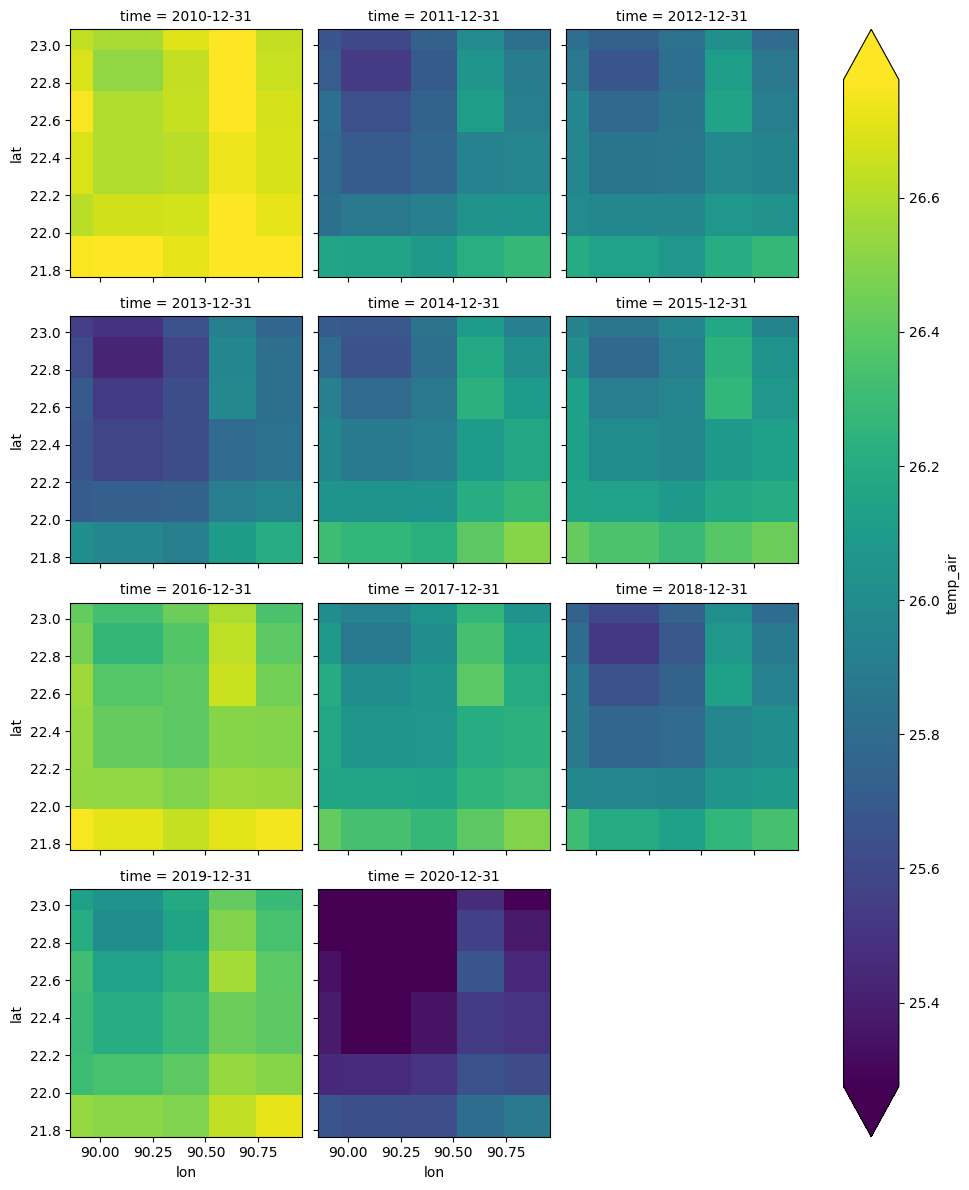

In [38]:
annual.temp_air.plot(
     x = 'lon',
     y = 'lat',
     col  = 'time',
     col_wrap = 3,
     robust = True
 )

In [39]:
!pip install xclim
import xclim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.4/378.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.5/305.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.8 MB/s eta 0:00:00


In [40]:
import xclim.indices as xindices

In [41]:
help(xindices.cold_spell_days)

Help on function cold_spell_days in module xclim.indices._threshold:

cold_spell_days(tas: 'xarray.DataArray', thresh: 'Quantified' = '-10 degC', window: 'int' = 5, freq: 'str' = 'YS-JUL', op: "Literal['<', 'lt', '<=', 'le']" = '<', resample_before_rl: 'bool' = True) -> 'xarray.DataArray'
    Cold spell days.

    The number of days that are part of cold spell events, defined as a sequence of consecutive days with mean daily
    temperature below a threshold (default: -10°C).

    Parameters
    ----------
    tas : xarray.DataArray
        Mean daily temperature.
    thresh : Quantified
        Threshold temperature below which a cold spell begins.
    window : int
        Minimum number of days with temperature below the threshold to qualify as a cold spell.
    freq : str
        Resampling frequency.
    op : {"<", "lt", "<=", "le"}
        Comparison operation. Default: "<".
    resample_before_rl : bool
        Determines if the resampling should take place before or after the ru

In [42]:
ds.temp_air.attrs['units'] = 'degC'
ds

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 3843, lon: 10, lat: 12)
Coordinates:
  * time      (time) datetime64[ns] 31kB 2010-01-01 2010-01-02 ... 2020-07-09
  * lon       (lon) float64 80B 89.91 90.02 90.13 90.24 ... 90.68 90.79 90.9
  * lat       (lat) float64 96B 21.82 21.93 22.04 22.15 ... 22.81 22.92 23.03
Data variables:
    temp_air  (time, lon, lat) float32 2MB 18.31 18.31 16.97 ... 29.4 29.4 29.29
Attributes: (12/36)
    date_range:               [284083200000, 1594252800000]
    description:              <p>ERA5 is the fifth generation ECMWF atmospher...
    keywords:                 ['climate', 'copernicus', 'dewpoint', 'ecmwf', ...
    max_mirrored_version:     1594797432309553
    period:                   1
    period_mapping:           [284083200000, 1594252800000]
    ...                       ...
    visualization_3_bands:    u_component_of_wind_10m
    visualization_3_max:      30.0
    visualization_3_min:      0.0
    visualization_3_name:     Daily mean u-component of wind at 10m
    visualization_3_palette:  #FFFFFF,#FFFF71,#DEFF00,#9EFF00,#77B038,#007E55...
    crs:                      EPSG:4326

In [43]:
cs_days = xindices.cold_spell_days(
    ds.temp_air,
    thresh = '-10 degC',
    window = 5,
    freq = 'YS-JUL'
)

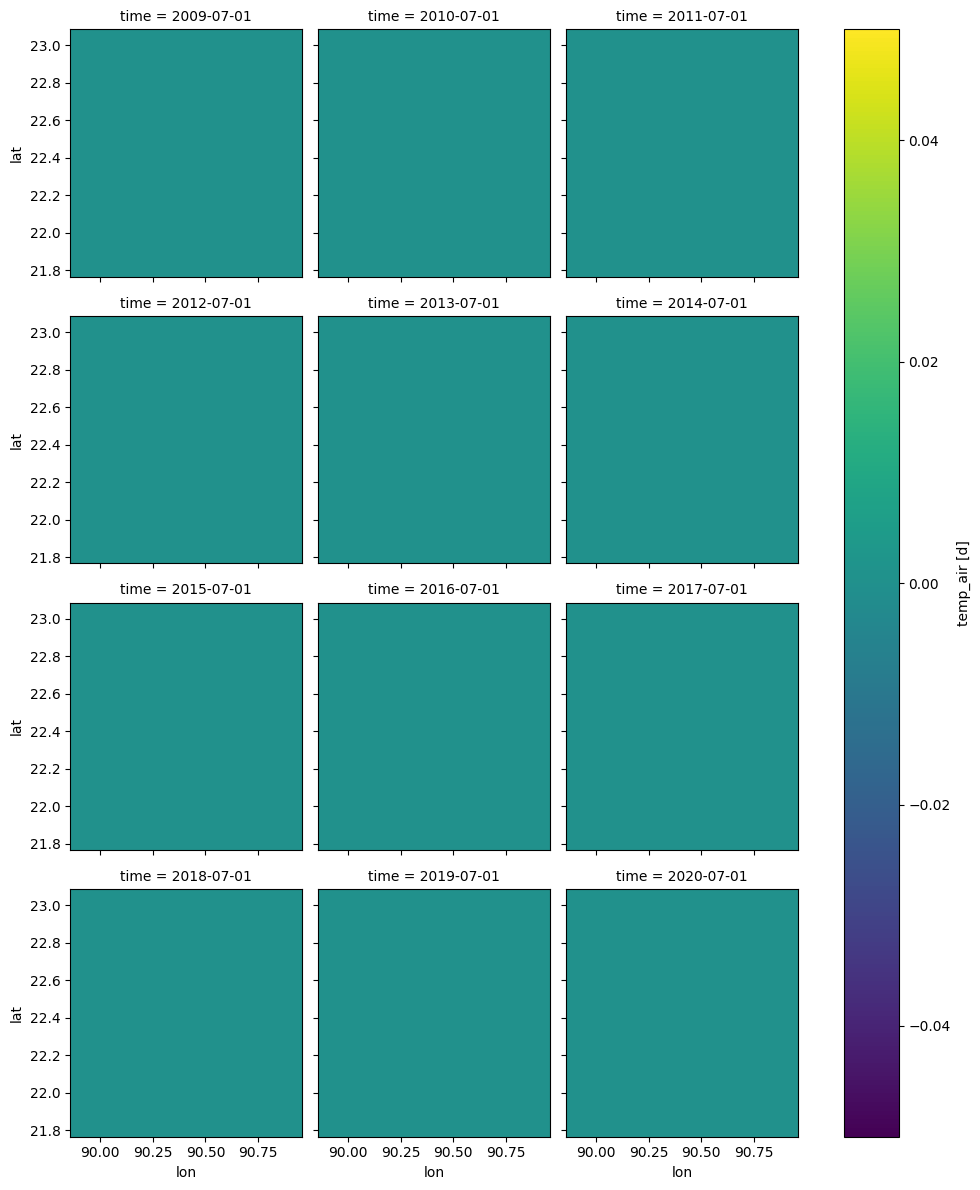

In [44]:
cs_days.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 3
)

In [45]:
help(xindices.cold_spell_frequency)


Help on function cold_spell_frequency in module xclim.indices._threshold:

cold_spell_frequency(tas: 'xarray.DataArray', thresh: 'Quantified' = '-10 degC', window: 'int' = 5, freq: 'str' = 'YS-JUL', op: "Literal['<', 'lt', '<=', 'le']" = '<', resample_before_rl: 'bool' = True) -> 'xarray.DataArray'
    Cold spell frequency.

    The number of cold spell events, defined as a sequence of consecutive {window} days with mean daily
    temperature below a {thresh}.

    Parameters
    ----------
    tas : xarray.DataArray
        Mean daily temperature.
    thresh : Quantified
        Threshold temperature below which a cold spell begins.
    window : int
        Minimum number of days with temperature below the threshold to qualify as a cold spell.
    freq : str
        Resampling frequency.
    op : {"<", "lt", "<=", "le"}
        Comparison operation. Default: "<".
    resample_before_rl : bool
        Determines if the resampling should take place before or after the run.

    Returns


In [46]:
cs_freq = xindices.cold_spell_frequency(
    ds.temp_air,
    thresh = '-10 degC',
    window = 5,
    freq = 'YS-JUL'
)

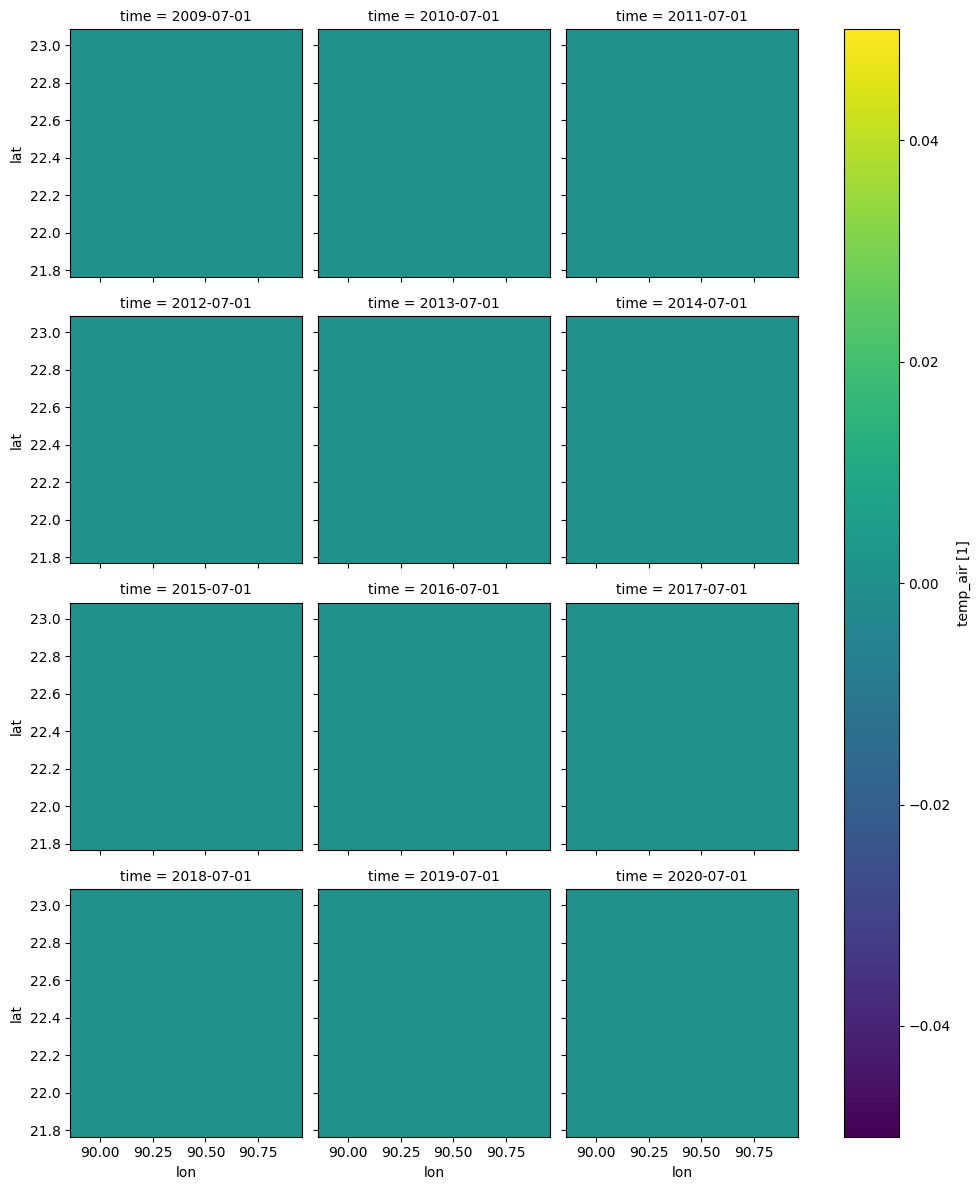

In [47]:
cs_freq.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 3,
)

In [48]:
help(xindices.cold_spell_max_length)


Help on function cold_spell_max_length in module xclim.indices._threshold:

cold_spell_max_length(tas: 'xarray.DataArray', thresh: 'Quantified' = '-10 degC', window: 'int' = 1, freq: 'str' = 'YS-JUL', op: "Literal['<', 'lt', '<=', 'le']" = '<', resample_before_rl: 'bool' = True) -> 'xarray.DataArray'
    Longest cold spell.

    Longest spell of low temperatures over a given period.
    Longest series of at least {window} consecutive days with temperature at or below {thresh}.

    Parameters
    ----------
    tas : xarray.DataArray
        Mean daily temperature.
    thresh : Quantified
        The temperature threshold needed to trigger a cold spell.
    window : int
        Minimum number of days with temperatures below the threshold to qualify as a cold spell.
    freq : str
        Resampling frequency.
    op : {"<", "lt", "<=", "le"}
        Comparison operation. Default: "<".
    resample_before_rl : bool
        Determines if the resampling should take place before or after t

In [49]:
cs_max_length = xindices.cold_spell_max_length(
    ds.temp_air,
    thresh = '-10 degC',
    window = 1,
    freq = 'YS-JUL'
)

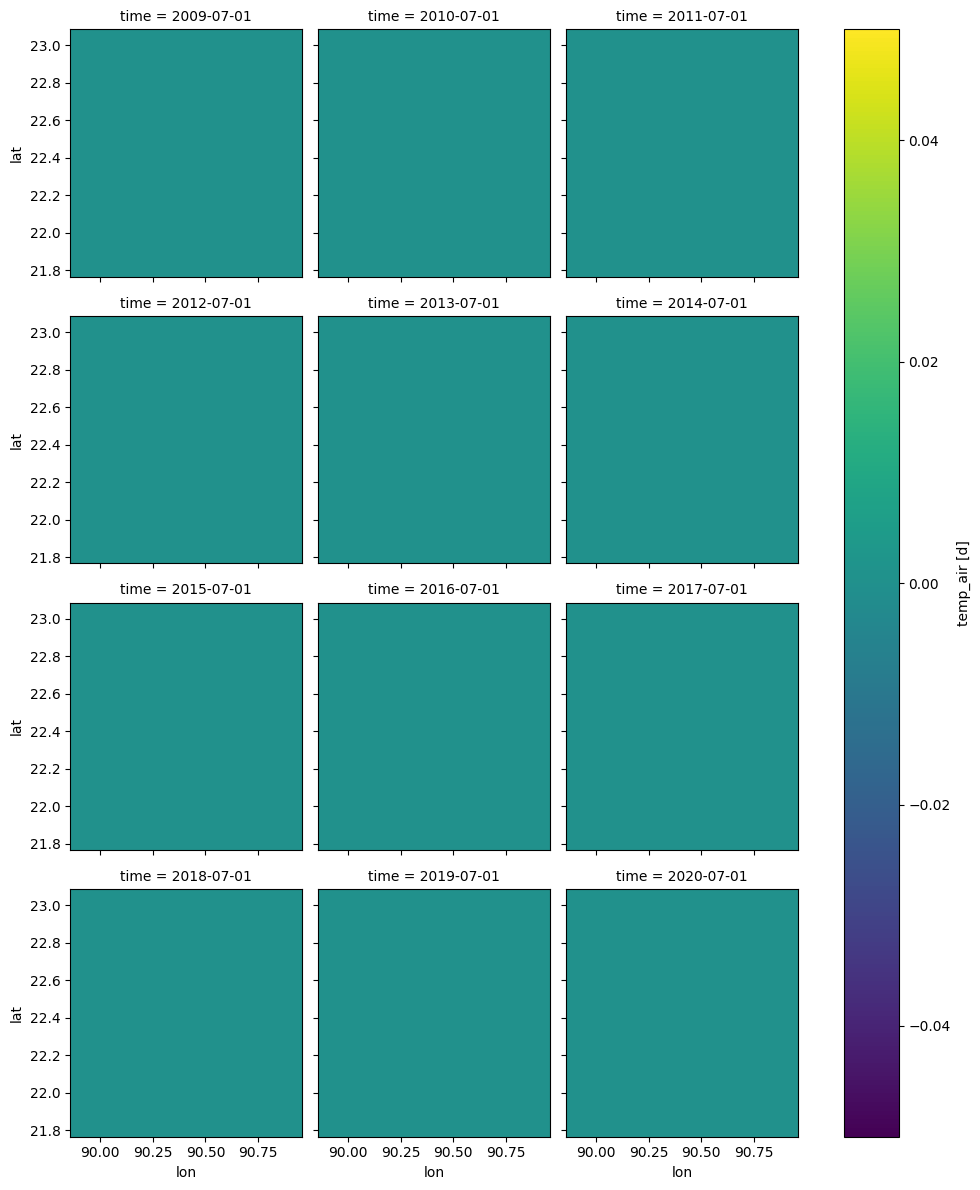

In [50]:
cs_max_length.plot(
    x ='lon',
    y = 'lat',
    col = 'time',
    col_wrap = 3
)

In [51]:
Fs = ds1 - 273.15

In [52]:
annual2 = Fs.resample(time = 'YE').mean('time')

annual2

<xarray.Dataset> Size: 10kB
Dimensions:   (time: 11, lon: 16, lat: 14)
Coordinates:
  * lon       (lon) float64 128B 88.14 88.25 88.36 88.47 ... 89.57 89.68 89.79
  * lat       (lat) float64 112B 25.09 25.2 25.31 25.42 ... 26.3 26.41 26.52
  * time      (time) datetime64[ns] 88B 2010-12-31 2011-12-31 ... 2020-12-31
Data variables:
    temp_air  (time, lon, lat) float32 10kB 25.95 25.95 25.8 ... 23.8 23.8 19.0
Attributes: (12/36)
    date_range:               [284083200000, 1594252800000]
    description:              <p>ERA5 is the fifth generation ECMWF atmospher...
    keywords:                 ['climate', 'copernicus', 'dewpoint', 'ecmwf', ...
    max_mirrored_version:     1594797432309553
    period:                   1
    period_mapping:           [284083200000, 1594252800000]
    ...                       ...
    visualization_3_bands:    u_component_of_wind_10m
    visualization_3_max:      30.0
    visualization_3_min:      0.0
    visualization_3_name:     Daily mean u-component of wind at 10m
    visualization_3_palette:  #FFFFFF,#FFFF71,#DEFF00,#9EFF00,#77B038,#007E55...
    crs:                      EPSG:4326

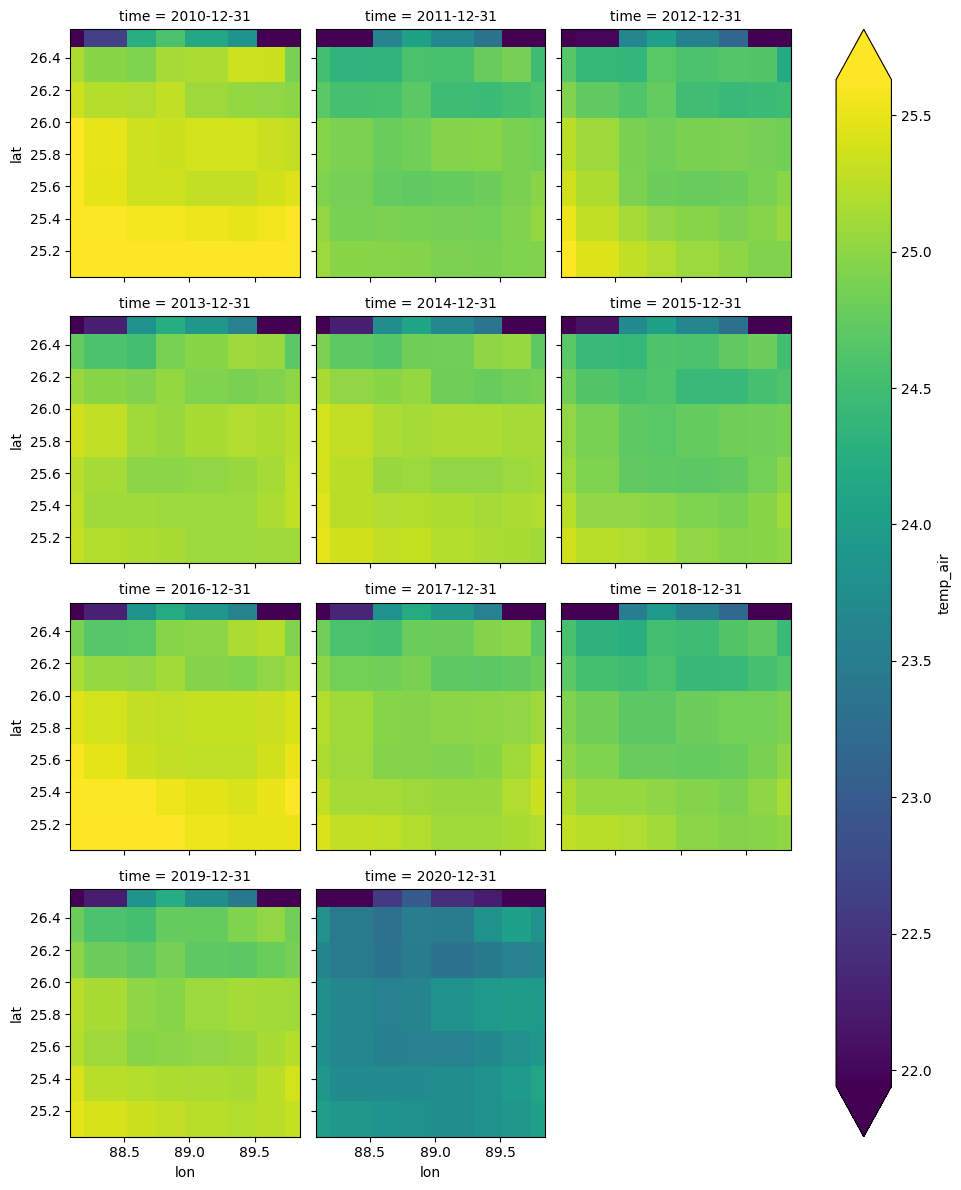

In [53]:
annual2.temp_air.plot(
     x = 'lon',
     y = 'lat',
     col  = 'time',
     col_wrap = 3,
     robust = True
 )

In [54]:
Fs.temp_air.attrs['units'] = 'degC'
Fs

<xarray.Dataset> Size: 3MB
Dimensions:   (time: 3843, lon: 16, lat: 14)
Coordinates:
  * time      (time) datetime64[ns] 31kB 2010-01-01 2010-01-02 ... 2020-07-09
  * lon       (lon) float64 128B 88.14 88.25 88.36 88.47 ... 89.57 89.68 89.79
  * lat       (lat) float64 112B 25.09 25.2 25.31 25.42 ... 26.3 26.41 26.52
Data variables:
    temp_air  (time, lon, lat) float32 3MB 14.44 14.44 14.41 ... 27.14 23.33
Attributes: (12/36)
    date_range:               [284083200000, 1594252800000]
    description:              <p>ERA5 is the fifth generation ECMWF atmospher...
    keywords:                 ['climate', 'copernicus', 'dewpoint', 'ecmwf', ...
    max_mirrored_version:     1594797432309553
    period:                   1
    period_mapping:           [284083200000, 1594252800000]
    ...                       ...
    visualization_3_bands:    u_component_of_wind_10m
    visualization_3_max:      30.0
    visualization_3_min:      0.0
    visualization_3_name:     Daily mean u-component of wind at 10m
    visualization_3_palette:  #FFFFFF,#FFFF71,#DEFF00,#9EFF00,#77B038,#007E55...
    crs:                      EPSG:4326

In [55]:
cs1_days = xindices.cold_spell_days(
    Fs.temp_air,
    thresh = '-10 degC',
    window = 5,
    freq = 'YS-JUL'
)

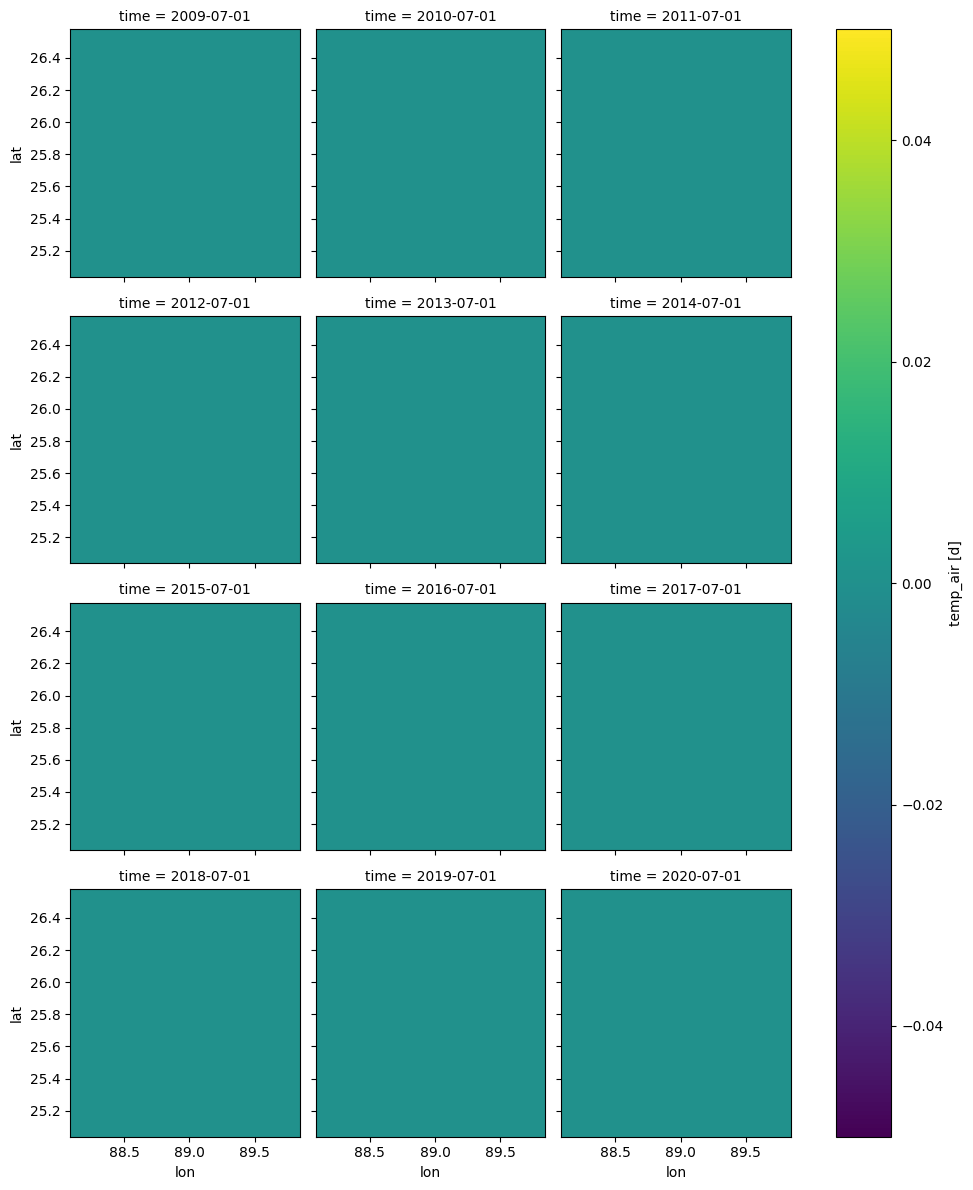

In [56]:
cs1_days.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 3
)

In [58]:
cs2_freq = xindices.cold_spell_frequency(
    Fs.temp_air,
    thresh = '-10 degC',
    window = 5,
    freq = 'YS-JUL'
)

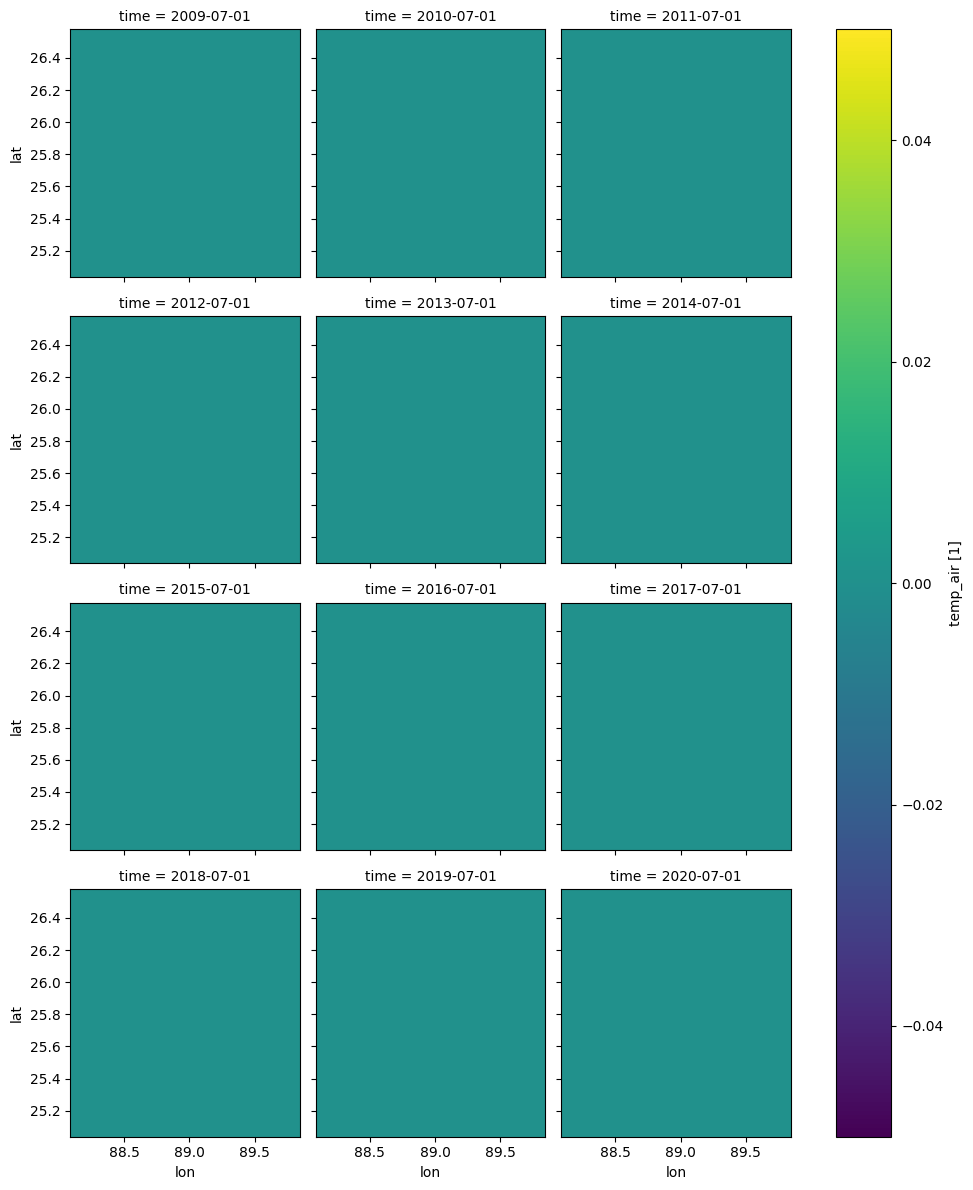

In [59]:
cs2_freq.plot(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 3,
)

In [60]:
cs2_max_length = xindices.cold_spell_max_length(
    Fs.temp_air,
    thresh = '-10 degC',
    window = 1,
    freq = 'YS-JUL'
)

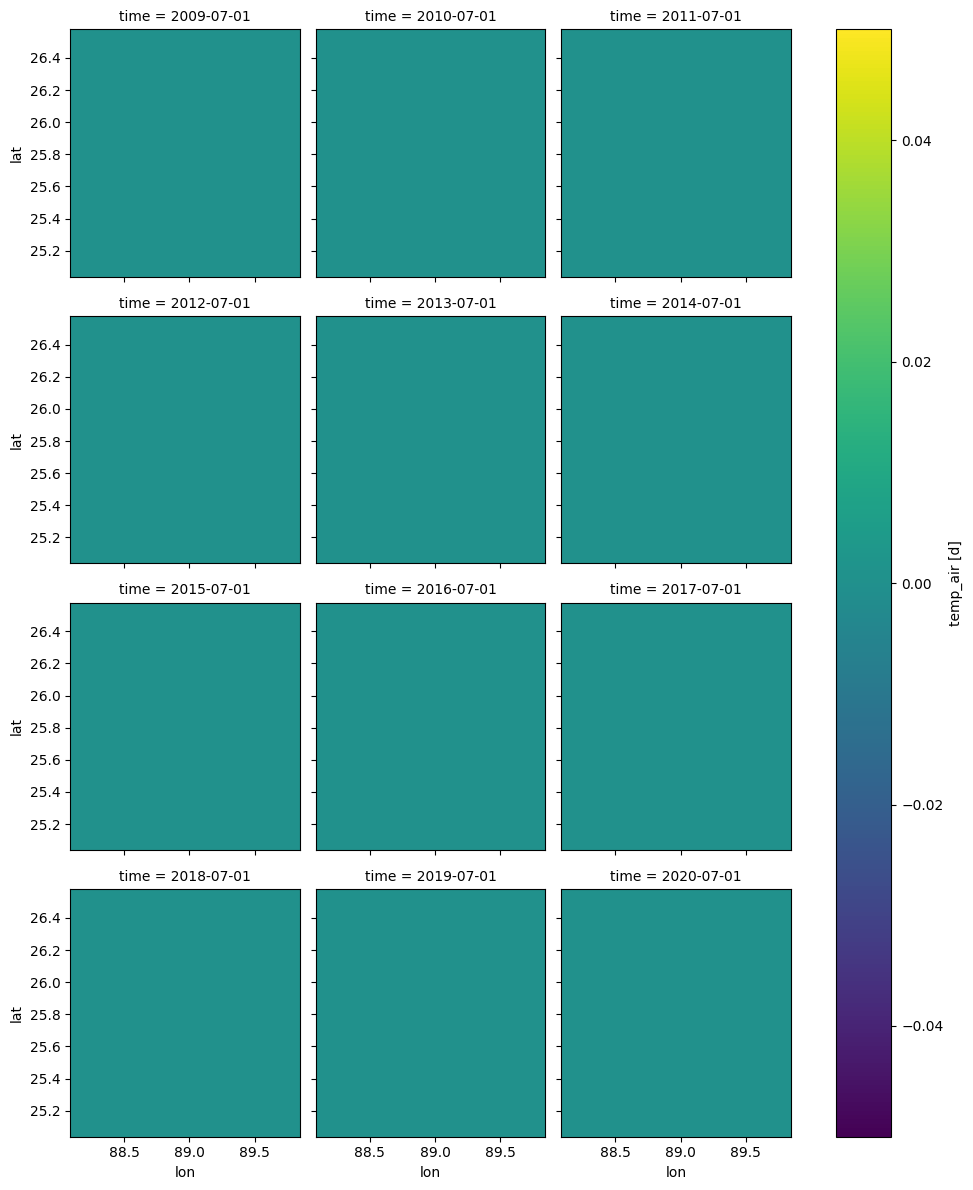

In [61]:
cs2_max_length.plot(
    x ='lon',
    y = 'lat',
    col = 'time',
    col_wrap = 3
)